In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [10]:
DATA_PATH = "../data/GC_F_features.csv"

FEATURE_COLUMNS = [
    "Close",
    "Volume",
    "RSI",
    "MACD",
    "MACD_Signal"
]

TARGET_COLUMN = "Close"

TIME_STEPS = 60
TRAIN_SIZE = 0.8

In [11]:
def create_sequences(features, target, time_steps):
    X = []
    y = []

    for i in range(time_steps, len(features)):

        # dane wejściowe (60 dni)
        X.append(features[i - time_steps:i])

        # wartość do przewidzenia
        y.append(target[i])

    return np.array(X), np.array(y)

In [12]:
# Tymczasowe dane testowe

np.random.seed(42)

days = 1000

demo_df = pd.DataFrame({
    "Close": np.cumsum(np.random.normal(0, 1, days)) + 1800,
    "Volume": np.random.randint(1000, 10000, days),
    "RSI": np.random.uniform(30, 70, days),
    "MACD": np.random.normal(0, 1, days),
    "MACD_Signal": np.random.normal(0, 1, days)
})

demo_df.head()

,Close,Volume,RSI,MACD,MACD_Signal
0,1800.496714,9619,31.305827,-0.042201,-0.889352
1,1800.358450,2895,64.742060,1.931439,1.378284
2,1801.006138,7090,32.587476,-0.101863,-0.362757
3,1802.529168,9508,68.232979,0.724410,-0.551561
4,1802.295015,7082,31.005678,0.010172,-1.343872


In [13]:
# Skalowanie danych

feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

# cechy wejściowe X
scaled_features = feature_scaler.fit_transform(
    demo_df[FEATURE_COLUMNS]
)

# wartość przewidywana Y
scaled_target = target_scaler.fit_transform(
    demo_df[[TARGET_COLUMN]]
)

print("scaled_features shape:", scaled_features.shape)
print("scaled_target shape:", scaled_target.shape)

scaled_features shape: (1000, 5)
scaled_target shape: (1000, 1)


In [14]:
# Tworzenie sekwencji czasowych

X, y = create_sequences(
    scaled_features,
    scaled_target,
    TIME_STEPS
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (940, 60, 5)
y shape: (940, 1)


In [15]:
# Podział train/test

train_size = int(len(X) * TRAIN_SIZE)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (752, 60, 5)
y_train: (752, 1)
X_test: (188, 60, 5)
y_test: (188, 1)


In [16]:
# Budowa modelu LSTM

model = Sequential()

# Pierwsza warstwa LSTM
model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

# Druga warstwa LSTM
model.add(
    LSTM(
        units=64,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

# Warstwa gęsta
model.add(Dense(32, activation="relu"))

# Wyjście
model.add(Dense(1))

# Kompilacja modelu
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

# Podsumowanie modelu
model.summary()

D:\Project stock-price-prediction\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,057 (207.25 KB)

 Trainable params: 53,057 (207.25 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0189 - val_loss: 0.0486
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0061 - val_loss: 0.0223
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0045 - val_loss: 0.0063
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0039 - val_loss: 0.0153
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0040 - val_loss: 0.0038
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0031 - val_loss: 0.0066
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0031 - val_loss: 0.0081
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0029 - val_loss: 0.0061
Epoch 9/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0026 - val_loss: 0.0116
Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 11/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0025 - val_loss: 0.0032
Epoch 12/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0

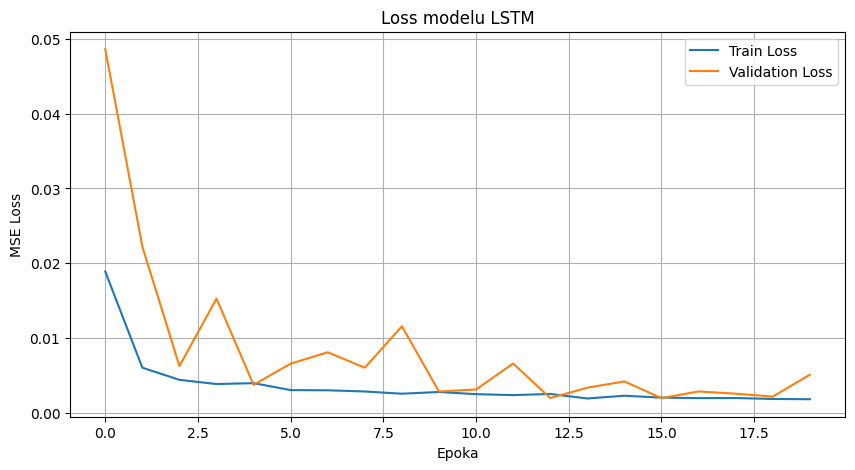

In [18]:
# Wykres strat modelu

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Loss modelu LSTM")
plt.xlabel("Epoka")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid(True)

plt.show()

In [19]:
# Predykcje modelu

y_pred_scaled = model.predict(X_test)

print(y_pred_scaled[:5])

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[0.2251122 ]
 [0.22437808]
 [0.22351286]
 [0.22436565]
 [0.22878654]]


In [20]:
# Zamiana z powrotem na prawdziwe ceny

y_pred = target_scaler.inverse_transform(y_pred_scaled)

y_test_real = target_scaler.inverse_transform(y_test)

print("Predykcje:")
print(y_pred[:5])

print("\nRzeczywiste wartości:")
print(y_test_real[:5])

Predykcje:
[[1793.2958]
 [1793.2634]
 [1793.2251]
 [1793.263 ]
 [1793.4585]]

Rzeczywiste wartości:
[[1793.91909202]
 [1794.1156468 ]
 [1795.14749134]
 [1793.66193097]
 [1793.92898123]]


In [21]:
mse = mean_squared_error(y_test_real, y_pred)
mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 10.058951367606554
RMSE: 3.171584992965907
MAE: 2.7461100895692097


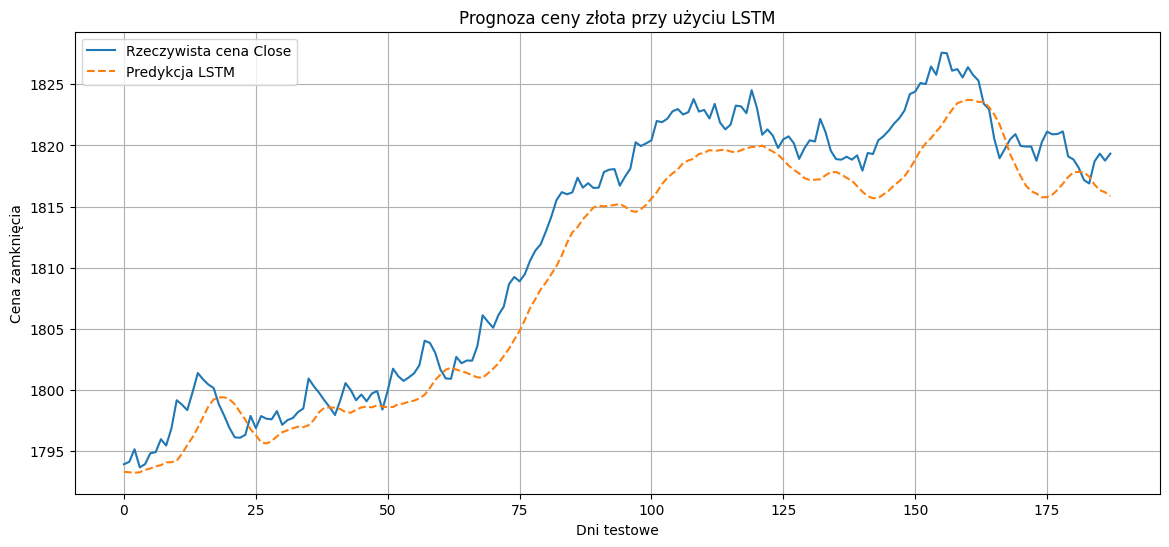

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(y_test_real, label="Rzeczywista cena Close")
plt.plot(y_pred, label="Predykcja LSTM", linestyle="--")

plt.title("Prognoza ceny złota przy użyciu LSTM")
plt.xlabel("Dni testowe")
plt.ylabel("Cena zamknięcia")
plt.legend()
plt.grid(True)

plt.show()